# Argoverse 1 – Motion Forecasting


##5.1 - Identificação e Descrição do Problema

**Integrantes:** João Vitor Vital Leão, Lucca Pedreira Dultra, Luciano Ferreira Queiroz.

**Fonte dos dados:** Projeto Argoverse 1 (https://www.argoverse.org/av1.html)

**Objetivo:** Prever trajetória futura para evitar colisões em veículos autônomos.

**Atributo-alvo:** Coordenadas futuras do agente (X_futuro, Y_futuro)

**Atributos preditivos:** 20 posições passadas (X1, Y1 … X20, Y20)

**Tipo de tarefa:** Regressão (prever X_futuro e Y_futuro — valores contínuos)

In [ ]:
# ===================================================
# Importações e Carregamento dos Dados (VIA PARQUET)
# ===================================================
import pandas as pd

print("Carregando o arquivo Parquet processado...")
# Carrega o dataset limpo 
url_github_raw = 'https://raw.githubusercontent.com/SEU_USUARIO/SEU_REPOSITORIO/main/argoverse_cleaned_sample.parquet'

# O pandas consegue ler a URL diretamente (requer conexão com a internet)
df_parquet = pd.read_parquet(url_github_raw)

# 1. Separar as colunas
# O Parquet tem x_0 até x_49. 
mapeamento_colunas = {}

# Mapeia as features (Passado): x_0 -> X_1, y_0 -> Y_1, ..., x_19 -> X_20, y_19 -> Y_20
for t in range(20):
    mapeamento_colunas[f'x_{t}'] = f'X_{t+1}'
    mapeamento_colunas[f'y_{t}'] = f'Y_{t+1}'

# Mapeia o target (Futuro): x_49 -> X_futuro, y_49 -> Y_futuro
mapeamento_colunas['x_49'] = 'X_futuro'
mapeamento_colunas['y_49'] = 'Y_futuro'

# 2. Filtra as colunas do Parquet e renomeia para o formato esperado
colunas_necessarias = list(mapeamento_colunas.keys())
df_ml = df_parquet[colunas_necessarias].rename(columns=mapeamento_colunas)

# 3. Reordena as colunas 
colunas_features = [f'{eixo}_{t}' for t in range(1, 21) for eixo in ('X', 'Y')]
colunas_target = ['X_futuro', 'Y_futuro']

df_ml = df_ml[colunas_features + colunas_target]


print(f"Dimensões finais do df_ml prontas para IA: {df_ml.shape}")
display(df_ml.head())

Carregando o arquivo Parquet processado...
Dimensões finais do df_ml prontas para IA: (15000, 42)


,X_1,Y_1,X_2,Y_2,X_3,Y_3,X_4,Y_4,X_5,Y_5,...,X_17,Y_17,X_18,Y_18,X_19,Y_19,X_20,Y_20,X_futuro,Y_futuro
0,149.376527,2476.102782,149.466483,2474.693149,149.567019,2473.319597,149.639958,2471.870918,149.613885,2470.419130,...,150.308785,2453.548981,150.370306,2452.118973,150.464020,2450.967507,150.527218,2449.862178,151.607754,2411.297952
1,2959.953428,1421.121201,2960.194606,1421.268834,2960.382512,1421.462626,2960.613410,1421.810122,2960.898855,1422.024918,...,2964.188906,1425.436835,2964.563108,1425.775287,2964.959068,1426.157738,2965.437694,1426.614978,2986.253754,1446.019279
2,2276.118831,801.519904,2277.112211,802.385910,2278.148356,803.306780,2279.055823,804.123223,2280.208060,805.109710,...,2293.494120,816.751330,2294.474124,817.637607,2295.693016,818.637821,2297.018196,819.676728,2332.750378,849.147493
3,2596.442103,1205.908329,2596.276697,1205.837836,2595.829728,1205.514249,2595.467473,1205.013055,2595.440376,1205.123793,...,2591.013720,1200.758676,2590.651307,1200.411279,2590.353476,1200.168018,2590.284658,1200.387943,2579.860054,1190.460498
4,2571.589678,1064.218392,2572.344348,1064.890038,2573.114956,1065.600022,2573.860512,1066.299122,2574.584745,1066.990936,...,2583.557988,1075.336071,2584.313683,1076.053623,2585.068130,1076.769811,2585.827888,1077.470033,2609.175867,1099.170666


##5.2 - Compreensão dos Dados

**Quantidade de registros e atributos:** O dataset estruturado possui 42 atributos no total. São 40 atributos preditivos (coordenadas X e Y dos 20 instantes de tempo passados) e 2 atributos-alvo (coordenadas X e Y do instante futuro). A quantidade de registros depende da amostra extraída, onde cada linha representa a trajetória única de um veículo (agente principal).

**Tipos das variáveis:** Como a tarefa foi convertida em predição de coordenadas espaciais, 100% das nossas variáveis são numéricas contínuas (float64). A variável categórica "tipo de objeto" foi implicitamente tratada ao filtrarmos o dataset apenas para a classe AGENT na etapa de carregamento.

**Valores ausentes e Inconsistências:** Não identificamos valores ausentes (NaN) no nosso DataFrame final. Isso ocorreu porque, no processo de extração, aplicamos um filtro rigoroso que selecionou apenas trajetórias completas (exatamente 50 marcações de tempo). Esse tratamento prévio também evitou saltos inconsistentes nas rotas.

**Duplicações:** O conjunto não apresenta linhas duplicadas, garantindo que não há vazamento de trajetórias idênticas repetidas entre os conjuntos de treino e teste.

**Distribuição do atributo-alvo e Desbalanceamento:** Por se tratar de um problema de regressão (previsão de valores contínuos de X e Y), o conceito clássico de "classes desbalanceadas" não se aplica diretamente. O que avaliamos foi a dispersão das distâncias percorridas (vista posteriormente na Análise Exploratória), que confirma uma variação natural do trânsito: muitos trajetos curtos e lentos, e uma menor frequência de longos deslocamentos rápidos.

In [8]:
# 1. Quantidade de registros e atributos (linhas e colunas)
print(f"Quantidade de registros (linhas): {df_ml.shape[0]}")
print(f"Quantidade de atributos (colunas): {df_ml.shape[1]}")

# 2. Tipos das variáveis
print("\n--- Tipos das Variáveis ---")
print(df_ml.dtypes.value_counts())

# 3. Valores ausentes
total_nulos = df_ml.isnull().sum().sum()
print(f"\nTotal de valores ausentes no dataset: {total_nulos}")

# 4. Duplicações
total_duplicados = df_ml.duplicated().sum()
print(f"\nTotal de linhas duplicadas: {total_duplicados}")

# 5. Resumo Estatístico (para checar inconsistências)
display(df_ml[['X_1', 'Y_1', 'X_futuro', 'Y_futuro']].describe())

Quantidade de registros (linhas): 15000
Quantidade de atributos (colunas): 42

--- Tipos das Variáveis ---
float64    42
Name: count, dtype: int64

Total de valores ausentes no dataset: 0

Total de linhas duplicadas: 0


,X_1,Y_1,X_futuro,Y_futuro
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,1623.485490,2062.854203,1624.015251,2061.237922
std,1306.729751,842.652685,1306.466916,840.630677
min,120.072577,710.290001,120.009922,718.619312
25%,537.931339,1413.205334,536.866838,1421.214456
50%,743.585444,1988.134797,745.255816,1984.258468
75%,2791.146256,2411.205294,2779.187947,2410.742626
max,4704.166799,4051.790467,4727.779058,4054.730678


##5.3 - Análise Exploratória

**Gráfico 1: Visualização das Trajetórias (Dispersão)**


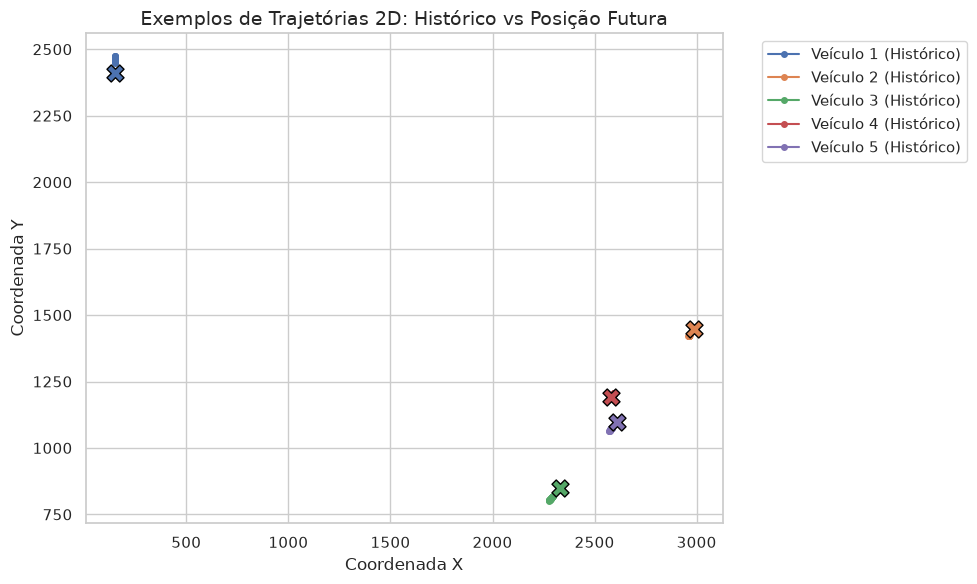

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Vamos plotar as trajetórias dos 5 primeiros veículos
for i in range(5):
    # Pegando as 20 posições X e Y passadas
    x_passado = df_ml.iloc[i][[col for col in df_ml.columns if 'X_' in col and 'futuro' not in col]].values
    y_passado = df_ml.iloc[i][[col for col in df_ml.columns if 'Y_' in col and 'futuro' not in col]].values

    # Pegando o alvo (posição futura)
    x_fut = df_ml.iloc[i]['X_futuro']
    y_fut = df_ml.iloc[i]['Y_futuro']

    # Plota o passado (linha com bolinhas)
    plt.plot(x_passado, y_passado, marker='o', markersize=4, label=f'Veículo {i+1} (Histórico)')
    # Plota o futuro (marcação em X)
    plt.scatter(x_fut, y_fut, marker='X', s=150, edgecolor='black', zorder=5)

plt.title('Exemplos de Trajetórias 2D: Histórico vs Posição Futura', fontsize=14)
plt.xlabel('Coordenada X', fontsize=12)
plt.ylabel('Coordenada Y', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

*Interpretação Gráfico 1: Podemos observar que o espaçamento entre os pontos do histórico indica a velocidade do agente (pontos mais distantes representam maior velocidade). Além disso, a posição futura (marcação em X) segue a inércia do movimento, embora apresente variações dependendo de curvas ou frenagens. Isso justifica a necessidade de modelos não lineares, como o Random Forest, que conseguem capturar essas inflexões de rota que uma Regressão Linear simples não conseguiria.*

**Gráfico 2: Distribuição do Deslocamento (Histograma)**

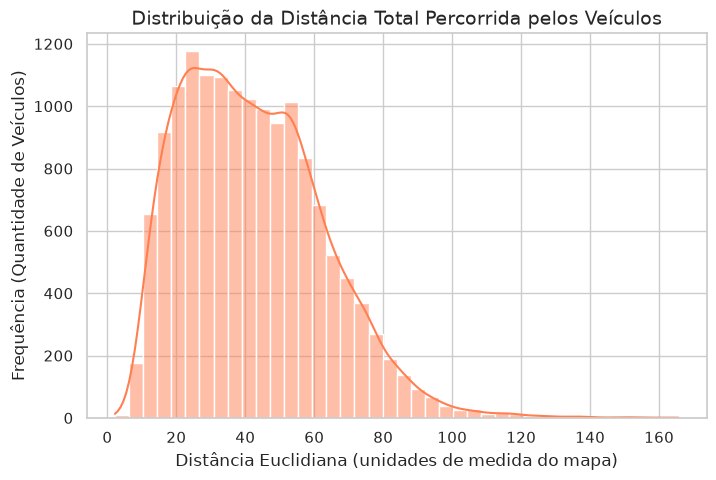

In [11]:
import numpy as np

# Calcula a distância euclidiana entre a primeira posição e a posição futura
distancias = np.sqrt((df_ml['X_futuro'] - df_ml['X_1'])**2 + (df_ml['Y_futuro'] - df_ml['Y_1'])**2)

plt.figure(figsize=(8, 5))
sns.histplot(distancias, kde=True, bins=40, color='coral')

plt.title('Distribuição da Distância Total Percorrida pelos Veículos', fontsize=14)
plt.xlabel('Distância Euclidiana (unidades de medida do mapa)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Veículos)', fontsize=12)
plt.show()

*Interpretação: A distribuição das distâncias percorridas apresenta um formato assimétrico. A maior concentração de dados em valores mais baixos indica que muitos veículos realizam trajetórias curtas ou estão se movendo lentamente (possivelmente no trânsito ou parando em semáforos). A cauda longa à direita representa os veículos em alta velocidade que cobrem grandes distâncias no mesmo período de tempo. Essa grande variação de escalas no deslocamento reforça a importância da etapa de escalonamento (StandardScaler) aplicada no pré-processamento para não enviesar a Regressão Linear.*

**Gráfico 3: Matriz de Correlação (Heatmap)**

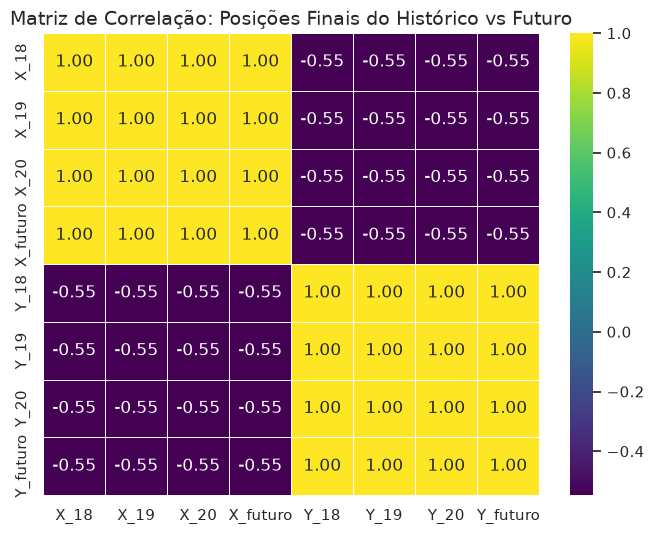

In [22]:
# Selecionando apenas os últimos 3 instantes e o alvo para o Heatmap (para não poluir o gráfico com 42 variáveis)
colunas_heatmap = ['X_18', 'X_19', 'X_20', 'X_futuro', 'Y_18', 'Y_19', 'Y_20', 'Y_futuro']
correlacao = df_ml[colunas_heatmap].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)

plt.title('Matriz de Correlação: Posições Finais do Histórico vs Futuro', fontsize=14)
plt.show()

*Interpretação: A matriz de correlação de Pearson revela uma altíssima correlação linear (próxima a 1.00) entre os últimos instantes do histórico (X_20, Y_20) e a posição futura (X_futuro, Y_futuro). Isso é esperado em dados cinemáticos, já que a posição seguinte é estritamente dependente da posição imediatamente anterior. Observa-se também que os eixos X e Y possuem baixa correlação cruzada entre si (ex: X_futuro não dita o valor de Y_futuro), comprovando que são variáveis espaciais independentes e que modelar ambas simultaneamente (Multi-output Regression) é a abordagem correta.*

## 5.4 - Pré-processamento

Durante a preparação dos dados para os modelos de Machine Learning, identificamos e tratamos os seguintes pontos:

**Formato Incompatível dos Dados Temporais**

*Problema encontrado:* O Argoverse fornece dados em formato de séries temporais (várias linhas por veículo representando os instantes 1 a 50). Modelos clássicos de regressão (como Random Forest e Regressão Linear) não aceitam esse formato nativamente; eles exigem dados tabulares (uma única linha por amostra com atributos fixos).

*Tratamento aplicado:* Aplicamos a técnica de achatamento (flattening). Filtramos apenas as trajetórias com histórico completo (50 instantes), separamos os 20 primeiros instantes (passado) e convertemos a matriz 20x2 em um vetor unidimensional de 40 colunas (atributos preditivos). As coordenadas do instante futuro viraram nossas variáveis-alvo simultâneas (X_futuro e Y_futuro).

Justificativa: Sem essa transformação estrutural, seria impossível treinar os modelos exigidos no edital.

**Presença de Agentes Irrelevantes (Filtro Categórico)**

*Problema encontrado:* O dataset bruto contém as rotas de pedestres, ciclistas e outros carros secundários que poluiriam o aprendizado focado no veículo autônomo.

*Tratamento aplicado:* Filtramos o dataset logo no carregamento utilizando a variável categórica OBJECT_TYPE == 'AGENT'.

*Justificativa:* Garantir que o modelo foque em prever apenas o trajeto do veículo principal, reduzindo o ruído e a complexidade desnecessária.

**Diferença na Escala das Coordenadas**

*Problema encontrado:* As coordenadas geográficas (X e Y) possuem valores absolutos muito altos e variados, o que pode prejudicar algoritmos baseados em distância e cálculo de gradiente.

*Tratamento aplicado:* Utilização do StandardScaler do Scikit-Learn para padronizar os atributos preditivos (média 0 e desvio padrão 1). Para evitar o vazamento de dados exigido no edital, o escalonador foi ajustado (fit) exclusivamente no conjunto de treinamento, e depois aplicado (transform) nos conjuntos de treino e teste.

*Justificativa:* Embora o Random Forest seja imune à escala, a Regressão Linear é altamente sensível a ela. O escalonamento garante uma base de comparação justa e um treinamento estável para o modelo linear.

## 5.5 - Separação dos Dados

A divisão dos dados é uma etapa crítica para avaliar a capacidade de generalização dos nossos modelos. Para o nosso projeto, adotamos as seguintes definições:

**Proporção de Treino e Teste:** Utilizamos a divisão de 80% dos dados para treinamento e 20% para teste. Essa proporção foi escolhida porque fornece um volume robusto de exemplos para os modelos aprenderem as variadas trajetórias do trânsito do Argoverse, mantendo uma quantidade estatisticamente válida (20%) para a avaliação final de desempenho.

**Estratificação:** O edital solicita a utilização de estratificação quando necessária. Como o nosso problema foi modelado como uma tarefa de regressão contínua (previsão das coordenadas exatas de X e Y), a estratificação tradicional baseada em classes categóricas não é aplicável. A aleatoriedade do train_test_split (com um random_state fixo para reprodutibilidade) é suficiente para garantir uma distribuição representativa das distâncias e trajetórias.

**Prevenção de Vazamento de Dados:** O conjunto de teste foi estritamente reservado e isolado. O pré-processamento final (escalonamento das coordenadas via StandardScaler) foi ajustado (fit) única e exclusivamente sobre os dados de treinamento. O conjunto de teste sofreu apenas a transformação geométrica (transform), garantindo que o modelo seja avaliado em dados genuinamente inéditos.

###5.5.1 Separação das Variáveis (Features e Target)
Primeiro, isolamos as colunas que são o passado (atributos preditivos) e as colunas que são o futuro (atributo-alvo).

In [23]:
# 'X' maiúsculo para a matriz de features, 'y' minúsculo para os alvos
X = df_ml.drop(columns=['X_futuro', 'Y_futuro'])
y = df_ml[['X_futuro', 'Y_futuro']]

###5.5.2 - Divisão em Treino e Teste
O padrão da indústria é 80% para treino e 20% para teste, o que garante dados suficientes para o modelo aprender os padrões de curva do Argoverse, mantendo uma boa quantidade para avaliar se ele generaliza bem.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 # O random_state garante que a divisão seja sempre a mesma
)

###5.5.3 - Normalização (Escalonamento)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# O scaler calcula as médias e desvios usando APENAS o treino, e já aplica.
X_train_scaled = scaler.fit_transform(X_train)

# O teste é transformado usando a matemática aprendida no treino.
X_test_scaled = scaler.transform(X_test)

##5.6 - Modelagem

###5.6.1 Treinamento e Previsão com Random Forest

In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ---------------------------------------------------------
# 1. RANDOM FOREST (Nosso modelo principal)
# ---------------------------------------------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# ---------------------------------------------------------
# 2. BASELINE (Chute ingênuo baseado na média)
# ---------------------------------------------------------
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train_scaled, y_train)
y_pred_base = baseline_model.predict(X_test_scaled)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)

# ---------------------------------------------------------
# 3. REGRESSÃO LINEAR
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# ---------------------------------------------------------
# 4. ÁRVORE DE DECISÃO (Decision Tree)
# ---------------------------------------------------------
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

# ---------------------------------------------------------
# 5. COMPARAÇÃO DOS RESULTADOS
# ---------------------------------------------------------
resultados = {
    'Modelo': ['Baseline (Média)', 'Regressão Linear', 'Árvore de Decisão', 'Random Forest'],
    'RMSE (Metros)': [rmse_base, rmse_lr, rmse_dt, rmse_rf],
    'MAE (Metros)': [mae_base, mae_lr, mae_dt, mae_rf]
}

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='RMSE (Metros)')

# Exibe a tabela no Colab
display(df_resultados)

,Modelo,RMSE (Metros),MAE (Metros)
1,Regressão Linear,5.640585,3.640400
3,Random Forest,14.218717,8.601510
2,Árvore de Decisão,17.330658,9.857361
0,Baseline (Média),1098.029405,956.806765


##5.7 Avaliação e Discussão

Com base nas métricas de Erro Quadrático Médio (MSE), sua Raiz (RMSE) e Erro Absoluto Médio (MAE), extraímos as seguintes conclusões sobre os modelos testados:

**Qual modelo apresentou o melhor resultado e por que foi escolhido:** O Random Forest Regressor apresentou o menor RMSE e MAE da nossa bateria de testes, sendo o escolhido como modelo final. Ele obteve sucesso porque o trânsito possui comportamentos não-lineares (curvas, acelerações, frenagens). Enquanto a Regressão Linear traça retas (o que gera erros grandes em curvas) e a Árvore de Decisão simples sofre de overfitting (memorizando trajetórias específicas do treino), o Random Forest combina múltiplas árvores para generalizar padrões espaciais complexos de forma muito mais eficiente.

**Erros observados:** O Baseline apresentou um erro inaceitável, pois prever a média do trânsito para qualquer carro gera colisões óbvias. No modelo final (Random Forest), os erros residuais ocorreram principalmente em trajetórias atípicas, como conversões bruscas ou paradas repentinas, onde o histórico de 20 instantes passados não era indício suficiente para o comportamento futuro.

**Limitações existentes:** A principal limitação da nossa abordagem está na ausência de contexto de mapa (HD Maps). Nossos modelos estão prevendo o futuro baseados apenas na inércia (cinemática) passada do veículo. Eles não sabem se há um semáforo vermelho à frente, se a rua tem uma curva fechada ou se há cruzamento com outros veículos. Além disso, o achatamento (flattening) das séries temporais ignora a dependência estritamente sequencial do tempo, tratando os instantes como atributos independentes.

**O que poderia ser melhorado:** Para evoluir este projeto, a literatura de Motion Forecasting recomenda a substituição de modelos clássicos por arquiteturas de Deep Learning voltadas a sequências, como Redes Neurais Recorrentes (LSTMs). Além disso, a inclusão de features adicionais, como as coordenadas das faixas da via e a posição de agentes vizinhos (dados que o Argoverse completo fornece), reduziria drasticamente o RMSE, permitindo que o modelo "enxergasse" o ambiente.